# Treasure Hunt Game Notebook

## Read and Review Your Starter Code
The theme of this project is a popular treasure hunt game in which the player needs to find the treasure before the pirate does. While you will not be developing the entire game, you will write the part of the game that represents the intelligent agent, which is a pirate in this case. The pirate will try to find the optimal path to the treasure using deep Q-learning.

<div class="alert alert-block alert-success" style="color:black;">
<b>To Begin:</b> Use this <b>TreasureHuntGame.ipynb</b> file to complete your assignment.
</div>

<div class="alert alert-block alert-danger" style="color: #333333;">
<b>GPU/CUDA/Memory Warnings/Errors:</b> You may receive errors referencing GPUs, CUDA, or memory. These are environment-based and can be ignored — the notebook forces CPU execution.
</div>

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
#  Force CPU BEFORE any TensorFlow import
# This prevents the 'cudaSetDevice() on GPU:0 failed: out of memory' crash.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

from __future__ import print_function
import sys, time, datetime, json, random
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, PReLU
import matplotlib.pyplot as plt
from TreasureMaze import TreasureMaze
from GameExperience import GameExperience
%matplotlib inline

print("TensorFlow version:", tf.__version__)
print("GPU devices visible:", tf.config.list_physical_devices('GPU'))
print("Running on CPU — ready.")

TensorFlow version: 2.17.0
GPU devices visible: []
Running on CPU — ready.


## Maze Object Generation

The following 8×8 matrix defines the maze. `1.0` = open cell, `0.0` = wall.

In [3]:
maze = np.array([
    [ 1.,  0.,  1.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  0.,  1.,  1.,  1.,  0.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  0.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  0.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  0.,  0.,  0.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.]
])

## Helper Functions and Global Variables

In [4]:
def show(qmaze):
    plt.grid('on')
    nrows, ncols = qmaze.maze.shape
    ax = plt.gca()
    ax.set_xticks(np.arange(0.5, nrows, 1))
    ax.set_yticks(np.arange(0.5, ncols, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    canvas = np.copy(qmaze.maze)
    for row, col in qmaze.visited:
        canvas[row, col] = 0.6
    pirate_row, pirate_col, _ = qmaze.state
    canvas[pirate_row, pirate_col] = 0.3   # pirate
    canvas[nrows-1, ncols-1] = 0.9         # treasure
    img = plt.imshow(canvas, interpolation='none', cmap='gray')
    return img

In [5]:
LEFT  = 0
UP    = 1
RIGHT = 2
DOWN  = 3

# Exploration parameters
epsilon       = 1.0
epsilon_min   = 0.05
epsilon_decay = 0.995
patience      = 10

actions_dict = {
    LEFT:  'left',
    UP:    'up',
    RIGHT: 'right',
    DOWN:  'down',
}
num_actions = len(actions_dict)

reward = -0.04


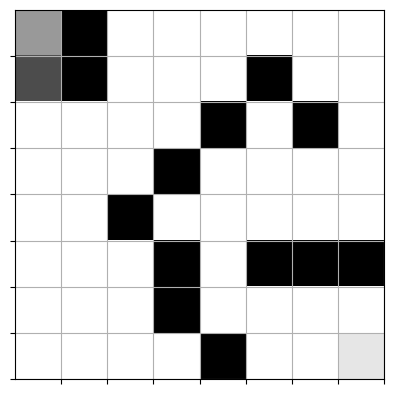

In [6]:
# Quick demo: one step down from start, visualise the maze
qmaze = TreasureMaze(maze)
canvas, reward, game_over = qmaze.act(DOWN)
print("reward =", reward)
show(qmaze)

<div class="alert alert-block alert-warning" style="color:black;">
<b>NOTE:</b> <b>play_game()</b> simulates a full game using the trained model. It runs until the pirate wins, loses, or hits the step limit.
</div>

In [7]:
def play_game(model, qmaze, pirate_cell, max_steps=None):
    qmaze.reset(pirate_cell)
    envstate = qmaze.observe()
    steps = 0
    if max_steps is None:
        max_steps = qmaze.maze.size * 4

    while steps < max_steps:
        state = np.asarray(envstate, dtype=np.float32)
        if state.ndim == 1:
            state = np.expand_dims(state, axis=0)
        q_values = model(state, training=False).numpy()
        action = np.argmax(q_values[0])
        envstate, reward, game_status = qmaze.act(action)
        steps += 1
        if game_status == 'win':
            return True
        elif game_status == 'lose':
            return False
    return False

<div class="alert alert-block alert-warning" style="color:black;">
<b>NOTE:</b> <b>completion_check()</b> verifies that the trained model can win from <i>every</i> valid free cell, not just one.
</div>

In [8]:
def completion_check(model, maze_or_qmaze, max_steps=None):
    if isinstance(maze_or_qmaze, TreasureMaze):
        qmaze = maze_or_qmaze
    else:
        qmaze = TreasureMaze(maze_or_qmaze)

    total = 0
    passed = 0
    for cell in qmaze.free_cells:
        if not qmaze.valid_actions(cell):
            continue
        total += 1
        if play_game(model, qmaze, cell, max_steps=max_steps):
            passed += 1

    print(f"Completion check: {passed}/{total} starting cells solved.")
    return passed == total

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note:</b> <b>build_model()</b> constructs the neural network. Two hidden layers with PReLU activations, compiled with Adam + MSE loss.
</div>

In [9]:
def build_model(maze):
    model = Sequential()
    model.add(Dense(maze.size, input_shape=(maze.size,)))
    model.add(PReLU())
    model.add(Dense(maze.size))
    model.add(PReLU())
    model.add(Dense(num_actions))
    model.compile(optimizer='adam', loss='mse')
    return model

<div class="alert alert-block alert-info" style="color:black;">
<b>train_step()</b> performs one gradient-descent update. It is defined <i>inside</i> qtrain() so it always references the correct model instance — this fixes the global-model bug from the starter code.
</div>

# Deep Q-Learning: qtrain()

<div class="alert alert-block alert-info" style="color:black;">
The goal is to find the best navigation sequence that reaches the treasure while maximising reward.
Training runs for up to <code>n_epoch</code> epochs. It stops early once the model passes <b>completion_check()</b> — meaning the pirate can solve the maze from every starting cell.
</div>

In [10]:
def qtrain(model, maze, **opt):
    """
    Deep Q-Learning training loop for the Treasure Hunt maze.

    Key improvements over starter:
      - train_step defined locally so it always uses the correct model.
      - Target network updated every target_update_freq epochs for stability.
      - Epsilon decays each epoch (exploration -> exploitation over time).
      - Per-epoch progress output: loss, win-rate, epsilon.
      - Early stopping once completion_check() passes.
    """
    global epsilon

    # ── Hyperparameters 
    n_epoch           = opt.get('n_epoch', 1000)
    max_memory        = opt.get('max_memory', 1000)
    data_size         = opt.get('data_size', 50)
    target_update_freq= opt.get('target_update_freq', 50)

    start_time = datetime.datetime.now()

    # ── Environment
    qmaze = TreasureMaze(maze)

    # ── Target network (stable frozen copy used inside GameExperience) 
    # Must be created BEFORE GameExperience, which requires both model + target_model.
    from tensorflow.keras.models import clone_model
    target_model = clone_model(model)
    target_model.set_weights(model.get_weights())

    # FIX 1: GameExperience.__init__ requires (model, target_model, max_memory).
    # The old call only passed model, causing the TypeError.
    experience = GameExperience(model, target_model, max_memory=max_memory)

    # ── Loss function and optimiser (local — avoids global-model bug) 
    loss_fn   = tf.keras.losses.MeanSquaredError()
    optimizer = tf.keras.optimizers.Adam()

    @tf.function
    def train_step(x, y):
        with tf.GradientTape() as tape:
            q_values = model(x, training=True)
            loss = loss_fn(y, q_values)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    # ── Tracking 
    win_history = []
    hsize       = qmaze.maze.size // 2   # rolling window for win rate
    win_rate    = 0.0

    print(f"{'Epoch':>6} | {'Loss':>9} | {'Episodes':>8} | {'Win Rate':>9} | {'Epsilon':>8} | Status")
    print("-" * 65)

    # ── Main training loop 
    for epoch in range(n_epoch):
        loss         = 0.0
        n_episodes   = 0

        # Reset to a random free cell each epoch
        agent_cell = random.choice(qmaze.free_cells)
        qmaze.reset(agent_cell)
        envstate = qmaze.observe()

        # ── Episode loop 
        while qmaze.game_status() == 'not_over':
            previous_envstate = envstate

            # Epsilon-greedy action selection
            valid_actions = qmaze.valid_actions()
            if not valid_actions:
                break
            if np.random.rand() < epsilon:
                # Explore: random valid move
                action = random.choice(valid_actions)
            else:
                # Exploit: best action from model
                state = np.asarray(previous_envstate, dtype=np.float32)
                if state.ndim == 1:
                    state = np.expand_dims(state, axis=0)
                q_values = model(state, training=False).numpy()
                action = np.argmax(q_values[0])

            # Take action, observe new state and reward
            envstate, reward, game_status = qmaze.act(action)

            # Store experience
            # FIX 2: GameExperience.get_data() checks `done` as a boolean.
            # game_status is a string ('win'/'lose'/'not_over'), so convert it.
            done = game_status != 'not_over'
            episode = [previous_envstate, action, reward, envstate, done]
            experience.remember(episode)
            n_episodes += 1

            # Train on a batch from replay memory
            # FIX 3: get_data() parameter is batch_size, not data_size.
            inputs, targets = experience.get_data(batch_size=data_size)
            batch_loss = train_step(
                tf.cast(inputs,  tf.float32),
                tf.cast(targets, tf.float32)
            )
            loss += float(batch_loss)

        # ── End of episode: record outcome 
        if qmaze.game_status() == 'win':
            win_history.append(1)
        else:
            win_history.append(0)

        # Rolling win rate over last hsize games
        if len(win_history) >= hsize:
            win_rate = sum(win_history[-hsize:]) / hsize

        # ── Decay exploration 
        if epsilon > epsilon_min:
            epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # ── Sync target network periodically 
        if (epoch + 1) % target_update_freq == 0:
            target_model.set_weights(model.get_weights())

        # ── Per-epoch output 
        avg_loss   = loss / max(n_episodes, 1)
        win_str    = f"{win_rate:.2f}" if len(win_history) >= hsize else "N/A"
        status_str = "WIN" if win_history[-1] == 1 else "   "
        print(
            f"{epoch+1:>6} | {avg_loss:>9.4f} | {n_episodes:>8} | "
            f"{win_str:>9} | {epsilon:>8.4f} | {status_str}"
        )

        # ── Early stopping: check full completion every 50 epochs after warm-up
        if win_rate >= 1.0 and (epoch + 1) >= hsize:
            if completion_check(model, qmaze):
                elapsed = datetime.datetime.now() - start_time
                print(f"\nSOLVED at epoch {epoch+1} in {str(elapsed)}")
                return elapsed

    total_time = datetime.datetime.now() - start_time
    print(f"\nTraining complete in: {str(total_time)}")
    return total_time

## Test Your Model

The cell below builds the model and runs training. Expect it to take several minutes on CPU.

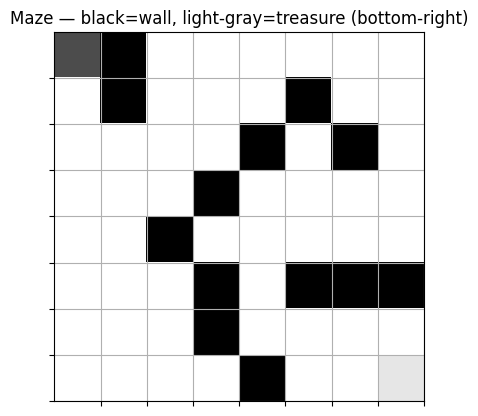

In [11]:
# Reset exploration to full before each fresh training run
epsilon = 1.0

qmaze = TreasureMaze(maze)
show(qmaze)
plt.title("Maze — black=wall, light-gray=treasure (bottom-right)")
plt.show()

In [12]:
model = build_model(maze)
model.summary()
qtrain(model, maze, n_epoch=1000, max_memory=8*maze.size, data_size=32, target_update_freq=50)

/home/codio/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_1 (PReLU)               │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,708 (34.02 KB)

 Trainable params: 8,708 (34.02 KB)

 Non-trainable params: 0 (0.00 B)

 Epoch |      Loss | Episodes |  Win Rate |  Epsilon | Status
-----------------------------------------------------------------
     1 |    0.0127 |      145 |       N/A |   0.9950 |    
     2 |    0.0023 |      144 |       N/A |   0.9900 |    
     3 |    0.0025 |      146 |       N/A |   0.9851 |    
     4 |    0.0026 |      149 |       N/A |   0.9801 |    
     5 |    0.0025 |       89 |       N/A |   0.9752 | WIN
     6 |    0.0025 |      150 |       N/A |   0.9704 |    
     7 |    0.0028 |      151 |       N/A |   0.9655 |    
     8 |    0.0026 |        1 |       N/A |   0.9607 | WIN
     9 |    0.0029 |       68 |       N/A |   0.9559 | WIN
    10 |    0.0029 |      141 |       N/A |   0.9511 |    
    11 |    0.0027 |      150 |       N/A |   0.9464 |    
    12 |    0.0023 |       14 |       N/A |   0.9416 | WIN
    13 |    0.0029 |        6 |       N/A |   0.9369 | WIN
    14 |    0.0030 |      143 |       N/A |   0.9322 |    
    15 |    0.0025 |      140 |       N/A |   

datetime.timedelta(seconds=824, microseconds=195478)

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note:</b> This cell runs the full completion check — verifies the pirate wins from every valid starting cell.
</div>

Completion check: 50/50 starting cells solved.
Fully solved: True


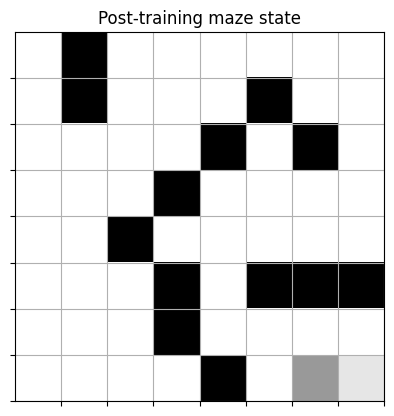

In [13]:
result = completion_check(model, qmaze)
print("Fully solved:", result)
show(qmaze)
plt.title("Post-training maze state")
plt.show()

This cell tests the model for one full game starting from the top-left corner.

Game result from (0,0): WIN


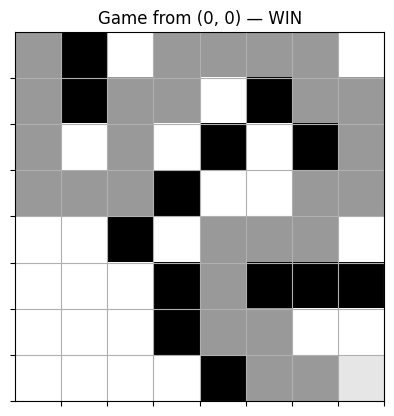

In [14]:
pirate_start = (0, 0)
won = play_game(model, qmaze, pirate_start)
print("Game result from (0,0):", "WIN" if won else "LOSE")
show(qmaze)
plt.title(f"Game from {pirate_start} — {'WIN' if won else 'LOSE'}")
plt.show()

## Analysis

**1. What is Deep Q-Learning?**  
Deep Q-Learning combines Q-learning (a reinforcement learning algorithm that learns action-value functions) with a neural network to approximate the Q-function. Rather than storing a table of Q-values for every state-action pair, the network takes the current environment state as input and outputs a Q-value for each possible action. The pirate learns which moves lead toward the treasure by repeatedly experiencing the maze and updating the network to reduce the gap between predicted and actual Q-values.

**2. Role of the Exploration Factor (Epsilon)**  
Epsilon controls the balance between exploration (choosing random valid actions to discover new paths) and exploitation (choosing the action with the highest predicted Q-value). It starts at 1.0 (fully random) and decays by a factor of 0.995 each epoch, reaching a floor of 0.05. Early in training the pirate explores freely; later it exploits its learned policy while retaining a small chance to discover shortcuts.

**3. Target Network**  
A target network is a periodically frozen copy of the main model. Q-targets computed from a changing network are unstable (the model chases a moving target). By holding the target network fixed for `target_update_freq` epochs and then syncing, training is significantly more stable.

**4. Experience Replay**  
Instead of training on each transition immediately, episodes are stored in a replay buffer (GameExperience) and random mini-batches are sampled for each training step. This breaks temporal correlations between consecutive transitions, preventing the network from overfitting to recent experience.

**References**  
- Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518, 529–533.  
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.